# Chapter 7: Curvature of surfaces

Source orientation: printed pages 159-178; PDF pages 164-182; sections 7.1-7.4.

This notebook is an original standalone teaching version of the assigned span. The local PDF was used only to orient the order of ideas and notation; no textbook prose, figures, page crops, hints, or solutions are reproduced.

## Chapter Question

How can a surface in `R^3` measure its bending in a way that agrees with tangent-plane deviation, variation of the unit normal, curvature of curves drawn on the surface, and the rule for carrying tangent vectors along a curve?

The chapter answer is that several local measurements keep returning to two related objects:

- the second fundamental form, a symmetric quadratic measurement of normal bending;
- the Weingarten map, the tangent-plane linear map obtained from the derivative of the Gauss map.

Parallel transport and the covariant derivative then separate what an observer on the surface can detect from what an outside observer in `R^3` sees.

## Route Through The Notebook

1. Build the second fundamental form from the height of a patch above its tangent plane.
2. Turn the Gauss map into data and check that the Weingarten map is self-adjoint for the first fundamental form.
3. Split the acceleration of a curve on a surface into normal curvature and geodesic curvature.
4. Compute covariant derivatives by projection and solve the parallel-transport equations along a latitude.
5. Run an applied lab and final sanity checks that verify identities, artifacts, and numerical residuals.


## Computational Translation Guide

| Chapter object | Computational representation | Inspection target | Main check |
| --- | --- | --- | --- |
| Surface patch `sigma(u,v)` | Arrays for `sigma`, `sigma_u`, `sigma_v`, second derivatives | Which directions span the tangent plane | `E G - F^2 > 0` |
| First fundamental form `I` | Metric matrix `[[E,F],[F,G]]` | Lengths and angles inside the tangent plane | positive determinant |
| Second fundamental form `II` | Symmetric matrix `[[L,M],[M,Ncoef]]` | Signed normal height to second order | exact symbolic examples |
| Gauss map `G` | Unit normal field, viewed as points on `S^2` | How much normals move as the base point moves | normal vectors have length one |
| Weingarten map `W=-dG` | Matrix `W = I^{-1} II` in the coordinate basis | Tangent directions are bent by a self-adjoint map | `W.T @ I = I @ W` |
| Normal curvature | Rayleigh quotient `II(v,v) / I(v,v)` for a direction | Curves with the same tangent direction have the same normal curvature | equals normal acceleration |
| Geodesic curvature | Tangential part of curve acceleration | What remains after subtracting the normal bending | `kappa^2 = kappa_n^2 + kappa_g^2` |
| Covariant derivative | Projection `v_dot - (v_dot dot N) N` | Surface-visible rate of change | tangent projection vanishes for parallel fields |
| Parallel transport | ODE for coordinate components of a tangent vector field | Length and angle preservation along a path | vector norm is preserved |

### Library Routing

- **SymPy** is used for exact checks on the sphere and cylinder because the fundamental-form identities are algebraic.
- **Plotly** is used for the Gauss map and parallel transport because the learner needs to rotate a surface and compare vectors in 3D.
- **Matplotlib** is used for durable annotated diagrams where labels, arrows, and a fixed comparison carry the idea.
- **SciPy** is used for the parallel-transport ODE so the notebook shows the differential equation rather than hiding it in a closed form.


In [1]:
from pathlib import Path
import json
import math
import sys

import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from scipy.integrate import solve_ivp

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the Pressley book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json

UNIT = "chapter-07"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
UNIT_ARTIFACT_ROOT = ARTIFACT_ROOT / UNIT
FIGURE_DIR = UNIT_ARTIFACT_ROOT / "figures"
INTERACTIVE_DIR = UNIT_ARTIFACT_ROOT / "interactive"
CHECK_DIR = UNIT_ARTIFACT_ROOT / "checks"
TABLE_DIR = UNIT_ARTIFACT_ROOT / "tables"
for directory in [FIGURE_DIR, INTERACTIVE_DIR, CHECK_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})


def book_rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


source_span = {
    "title": "Curvature of surfaces",
    "unit": UNIT,
    "printed_pages": "159-178",
    "pdf_pages": "164-182",
    "sections": "7.1-7.4",
    "source_use": "orientation only; original notebook prose and visuals",
}

visual_storyboard = {
    "chapter_goal": "Relate II, Gauss/Weingarten maps, curve curvature decomposition, and parallel transport on surfaces.",
    "visual_sequence": [
        {
            "concept": "second fundamental form",
            "representation": "quadratic graph above its tangent plane with direction-dependent signed height",
            "library": "Matplotlib",
            "artifact": "figures/second-fundamental-form-deviation.png",
            "inspection_target": "directions whose normal height is positive, negative, or zero",
            "validation": "symmetric II matrix and symbolic sphere/cylinder examples",
        },
        {
            "concept": "Gauss map and Weingarten map",
            "representation": "paraboloid normals sent to the unit sphere, plus matrix residuals",
            "library": "Plotly and NumPy",
            "artifact": "interactive/gauss-map-paraboloid.html",
            "inspection_target": "normal vectors on the surface and their image points on S^2",
            "validation": "unit normals and W.T @ I = I @ W residual",
        },
        {
            "concept": "normal and geodesic curvature",
            "representation": "latitude acceleration split into normal and tangential components",
            "library": "Matplotlib and NumPy",
            "artifact": "figures/normal-geodesic-curvature-latitude.png",
            "inspection_target": "which acceleration component is visible inside the surface",
            "validation": "kappa^2 = kappa_n^2 + kappa_g^2",
        },
        {
            "concept": "covariant derivative and parallel transport",
            "representation": "transported tangent vectors along a non-equatorial latitude",
            "library": "SciPy ODE and Plotly",
            "artifact": "interactive/parallel-transport-latitude.html",
            "inspection_target": "transported vector stays tangent and preserves length while drifting from the path tangent",
            "validation": "projected derivative residual and norm preservation",
        },
    ],
}

source_span_path = save_json(source_span, UNIT, "checks", "source-span.json", root=ARTIFACT_ROOT)
storyboard_path = save_json(visual_storyboard, UNIT, "checks", "visual-storyboard.json", root=ARTIFACT_ROOT)
(source_span, book_rel(storyboard_path))


({'title': 'Curvature of surfaces',
  'unit': 'chapter-07',
  'printed_pages': '159-178',
  'pdf_pages': '164-182',
  'sections': '7.1-7.4',
  'source_use': 'orientation only; original notebook prose and visuals'},
 'artifacts/chapter-07/checks/visual-storyboard.json')

## 1. Second Fundamental Form As Normal Deviation

Near a point, a patch can be compared with its tangent plane. The first-order terms lie in the tangent plane, so the first nonzero normal height is quadratic:

`normal height ~= 1/2 (L du^2 + 2 M du dv + Ncoef dv^2)`.

The figure uses a graph whose tangent plane at the origin is horizontal. The colored vertical bars show the signed height predicted by the second fundamental form in different tangent directions. Positive and negative bars mean the surface bends to opposite sides of the tangent plane; zero directions are asymptotic directions for this local model.


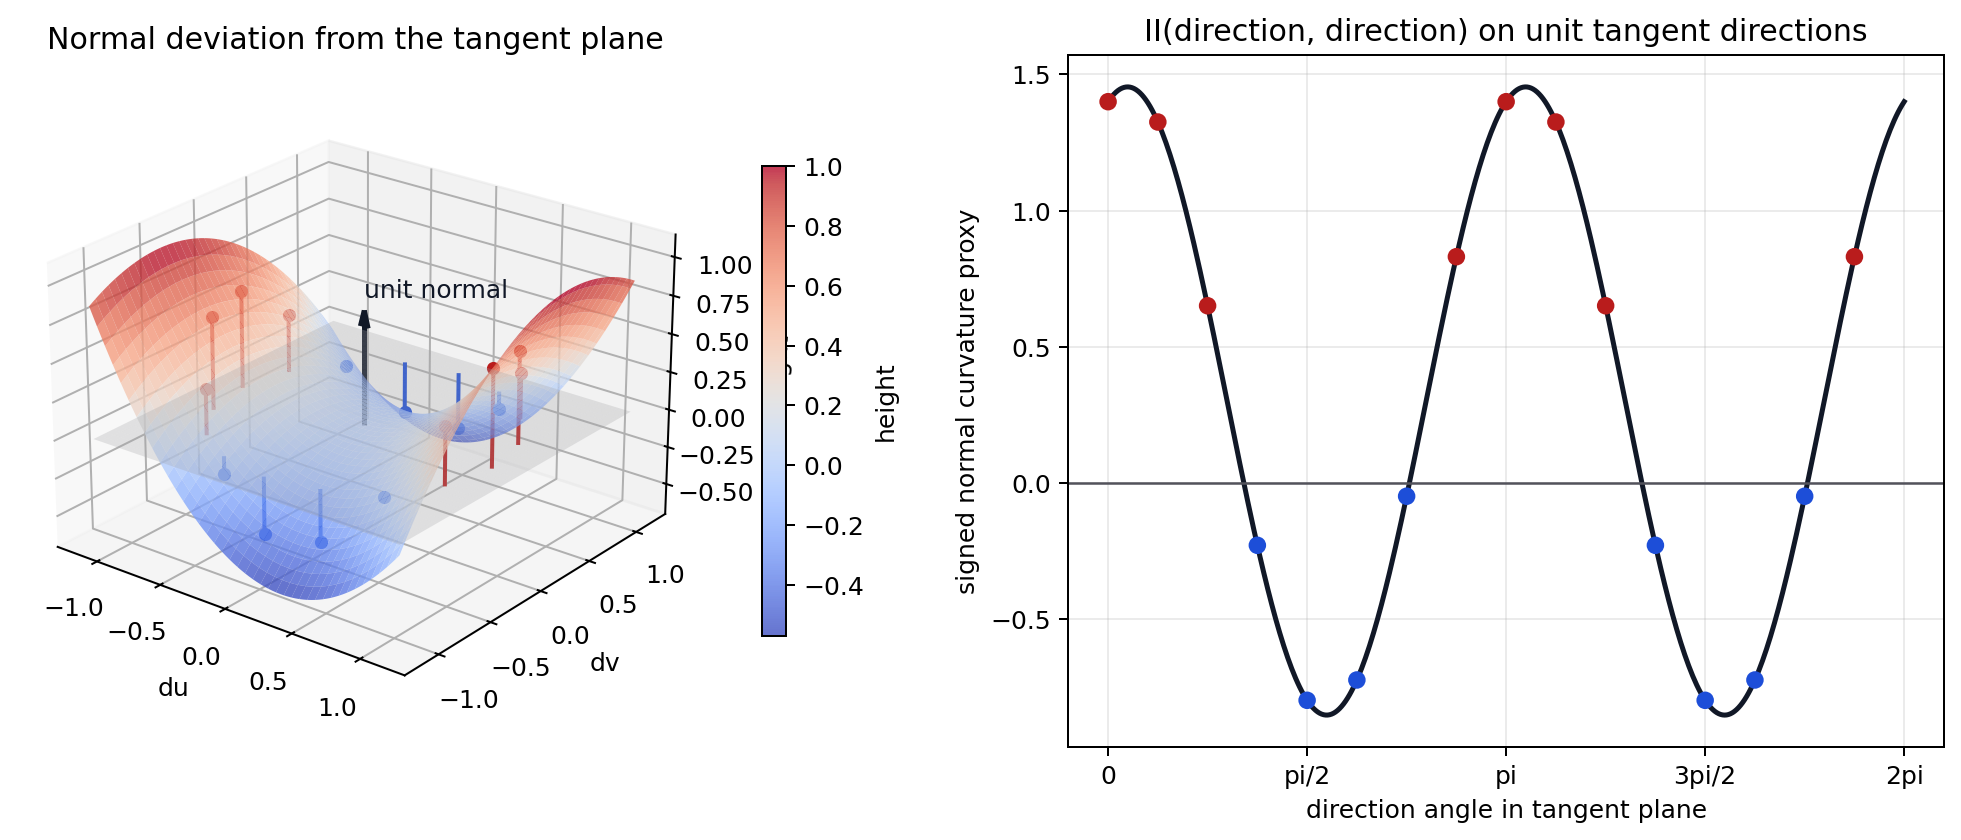

,check,value
0,sphere II equals I with inward normal,True
1,cylinder II is dv^2 with inward normal,True
2,quadratic model has both signs,True


In [2]:
quad_II = np.array([[1.4, 0.35], [0.35, -0.8]], dtype=float)


def quadratic_height(u, v):
    return 0.5 * (quad_II[0, 0] * u**2 + 2 * quad_II[0, 1] * u * v + quad_II[1, 1] * v**2)


grid = np.linspace(-1.15, 1.15, 80)
U, V = np.meshgrid(grid, grid)
Z = quadratic_height(U, V)

fig = plt.figure(figsize=(11, 4.8))
ax = fig.add_subplot(1, 2, 1, projection="3d")
surf = ax.plot_surface(U, V, Z, cmap="coolwarm", alpha=0.78, linewidth=0, antialiased=True)
ax.plot_surface(U, V, np.zeros_like(Z), color="#d4d4d8", alpha=0.28, linewidth=0)
ax.quiver(0, 0, 0, 0, 0, 0.75, color="#111827", linewidth=2, arrow_length_ratio=0.15)
ax.text(0, 0, 0.83, "unit normal", color="#111827")

angles = np.linspace(0, 2 * np.pi, 17)[:-1]
radius = 0.95
for angle in angles:
    u0 = radius * np.cos(angle)
    v0 = radius * np.sin(angle)
    z0 = quadratic_height(u0, v0)
    color = "#b91c1c" if z0 >= 0 else "#1d4ed8"
    ax.plot([u0, u0], [v0, v0], [0, z0], color=color, linewidth=1.6)
    ax.scatter([u0], [v0], [z0], color=color, s=18)

ax.set_title("Normal deviation from the tangent plane")
ax.set_xlabel("du")
ax.set_ylabel("dv")
ax.set_zlabel("height")
ax.view_init(elev=24, azim=-52)
ax.set_box_aspect((1, 1, 0.7))

ax2 = fig.add_subplot(1, 2, 2)
unit_dirs = np.column_stack([np.cos(angles), np.sin(angles)])
q_values = np.einsum("ni,ij,nj->n", unit_dirs, quad_II, unit_dirs)
angle_dense = np.linspace(0, 2 * np.pi, 400)
dir_dense = np.column_stack([np.cos(angle_dense), np.sin(angle_dense)])
q_dense = np.einsum("ni,ij,nj->n", dir_dense, quad_II, dir_dense)
ax2.plot(angle_dense, q_dense, color="#111827", linewidth=2)
ax2.scatter(angles, q_values, c=np.where(q_values >= 0, "#b91c1c", "#1d4ed8"), zorder=3)
ax2.axhline(0, color="#52525b", linewidth=1)
ax2.set_title("II(direction, direction) on unit tangent directions")
ax2.set_xlabel("direction angle in tangent plane")
ax2.set_ylabel("signed normal curvature proxy")
ax2.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax2.set_xticklabels(["0", "pi/2", "pi", "3pi/2", "2pi"])
fig.colorbar(surf, ax=ax, shrink=0.68, pad=0.08, label="height")
fig.tight_layout()

second_form_path = FIGURE_DIR / "second-fundamental-form-deviation.png"
fig.savefig(second_form_path, bbox_inches="tight")
plt.close(fig)

# Exact source-aligned checks: sphere in latitude-longitude coordinates and cylinder.
theta, phi, u, v = sp.symbols("theta phi u v", real=True)
sphere = sp.Matrix([sp.cos(theta) * sp.cos(phi), sp.cos(theta) * sp.sin(phi), sp.sin(theta)])
sphere_theta = sphere.diff(theta)
sphere_phi = sphere.diff(phi)
sphere_normal_inward = -sphere
sphere_E = sp.simplify(sphere_theta.dot(sphere_theta))
sphere_F = sp.simplify(sphere_theta.dot(sphere_phi))
sphere_G = sp.simplify(sphere_phi.dot(sphere_phi))
sphere_L = sp.simplify(sphere_theta.diff(theta).dot(sphere_normal_inward))
sphere_M = sp.simplify(sphere_theta.diff(phi).dot(sphere_normal_inward))
sphere_Ncoef = sp.simplify(sphere_phi.diff(phi).dot(sphere_normal_inward))

cylinder = sp.Matrix([sp.cos(v), sp.sin(v), u])
cyl_u = cylinder.diff(u)
cyl_v = cylinder.diff(v)
cyl_normal_inward = sp.Matrix([-sp.cos(v), -sp.sin(v), 0])
cyl_L = sp.simplify(cyl_u.diff(u).dot(cyl_normal_inward))
cyl_M = sp.simplify(cyl_u.diff(v).dot(cyl_normal_inward))
cyl_Ncoef = sp.simplify(cyl_v.diff(v).dot(cyl_normal_inward))

symbolic_checks = {
    "sphere_inward_orientation": {
        "first_form": {"E": str(sphere_E), "F": str(sphere_F), "G": str(sphere_G)},
        "second_form": {"L": str(sphere_L), "M": str(sphere_M), "Ncoef": str(sphere_Ncoef)},
        "II_equals_I": bool(
            sp.simplify(sphere_E - sphere_L) == 0
            and sp.simplify(sphere_F - sphere_M) == 0
            and sp.simplify(sphere_G - sphere_Ncoef) == 0
        ),
    },
    "unit_cylinder_inward_orientation": {
        "second_form": {"L": str(cyl_L), "M": str(cyl_M), "Ncoef": str(cyl_Ncoef)},
        "II_is_dv_squared": bool(cyl_L == 0 and cyl_M == 0 and cyl_Ncoef == 1),
    },
    "local_quadratic_model": {
        "II_matrix": quad_II.tolist(),
        "eigenvalues": np.linalg.eigvalsh(quad_II).round(8).tolist(),
        "has_positive_and_negative_normal_bending": bool(np.linalg.det(quad_II) < 0),
    },
}
symbolic_path = save_json(symbolic_checks, UNIT, "checks", "symbolic-fundamental-forms.json", root=ARTIFACT_ROOT)

display_artifact(second_form_path, width=920)
pd.DataFrame(
    [
        {"check": "sphere II equals I with inward normal", "value": symbolic_checks["sphere_inward_orientation"]["II_equals_I"]},
        {"check": "cylinder II is dv^2 with inward normal", "value": symbolic_checks["unit_cylinder_inward_orientation"]["II_is_dv_squared"]},
        {"check": "quadratic model has both signs", "value": symbolic_checks["local_quadratic_model"]["has_positive_and_negative_normal_bending"]},
    ]
)


## 2. Gauss Map And Weingarten Map

For an oriented surface, the Gauss map sends a point of the surface to its unit normal on the unit sphere. The derivative of that map measures how fast the normal changes. The Weingarten map is `W = -dG`, expressed in coordinates by the matrix equation

`II(v,w) = I(Wv,w)`, so `W = I^{-1} II`.

The interactive artifact uses the paraboloid `z = u^2 + v^2`. On the left, inspect the unit normals attached to the surface. On the right, inspect the corresponding points on `S^2`. The check table samples the metric matrix `I`, second-form matrix `II`, and verifies that `W` is self-adjoint for `I`.


In [3]:
def paraboloid(u, v):
    return np.array([u, v, u**2 + v**2], dtype=float)


def paraboloid_normal(u, v):
    denom = math.sqrt(1 + 4 * u**2 + 4 * v**2)
    return np.array([-2 * u / denom, -2 * v / denom, 1 / denom], dtype=float)


def paraboloid_forms(u, v):
    denom = math.sqrt(1 + 4 * u**2 + 4 * v**2)
    I = np.array([[1 + 4 * u**2, 4 * u * v], [4 * u * v, 1 + 4 * v**2]], dtype=float)
    II = np.array([[2 / denom, 0.0], [0.0, 2 / denom]], dtype=float)
    W = np.linalg.solve(I, II)
    return I, II, W


grid = np.linspace(-1.2, 1.2, 55)
U, V = np.meshgrid(grid, grid)
Z = U**2 + V**2
D = np.sqrt(1 + 4 * U**2 + 4 * V**2)
NX, NY, NZ = -2 * U / D, -2 * V / D, 1 / D

sphere_theta_grid = np.linspace(0.02, np.pi - 0.02, 45)
sphere_phi_grid = np.linspace(0, 2 * np.pi, 70)
TH, PH = np.meshgrid(sphere_theta_grid, sphere_phi_grid)
SX = np.sin(TH) * np.cos(PH)
SY = np.sin(TH) * np.sin(PH)
SZ = np.cos(TH)

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("Paraboloid with unit normals", "Image of the Gauss map on S^2"),
)
fig.add_trace(
    go.Surface(x=U, y=V, z=Z, colorscale="Viridis", opacity=0.84, showscale=False),
    row=1,
    col=1,
)
fig.add_trace(
    go.Surface(x=SX, y=SY, z=SZ, colorscale=[[0, "#f8fafc"], [1, "#dbeafe"]], opacity=0.32, showscale=False),
    row=1,
    col=2,
)

sample_values = np.linspace(-1.0, 1.0, 5)
normal_scale = 0.32
for a in sample_values:
    for b in sample_values:
        p0 = paraboloid(a, b)
        n0 = paraboloid_normal(a, b)
        p1 = p0 + normal_scale * n0
        fig.add_trace(
            go.Scatter3d(x=[p0[0], p1[0]], y=[p0[1], p1[1]], z=[p0[2], p1[2]], mode="lines", line=dict(color="#ef4444", width=4), showlegend=False),
            row=1,
            col=1,
        )
        fig.add_trace(
            go.Scatter3d(x=[0, n0[0]], y=[0, n0[1]], z=[0, n0[2]], mode="lines", line=dict(color="#2563eb", width=3), showlegend=False),
            row=1,
            col=2,
        )
        fig.add_trace(
            go.Scatter3d(x=[n0[0]], y=[n0[1]], z=[n0[2]], mode="markers", marker=dict(color="#1d4ed8", size=4), showlegend=False),
            row=1,
            col=2,
        )

fig.update_layout(
    height=610,
    margin=dict(l=0, r=0, t=50, b=0),
    scene=dict(aspectmode="data", xaxis_title="u", yaxis_title="v", zaxis_title="z"),
    scene2=dict(aspectmode="data", xaxis_title="Nx", yaxis_title="Ny", zaxis_title="Nz"),
)
gauss_map_path = INTERACTIVE_DIR / "gauss-map-paraboloid.html"
fig.write_html(gauss_map_path, include_plotlyjs=True, full_html=True)

records = []
for a in [-0.9, -0.25, 0.0, 0.55, 0.9]:
    for b in [-0.7, 0.0, 0.65]:
        I, II, W = paraboloid_forms(a, b)
        n0 = paraboloid_normal(a, b)
        records.append(
            {
                "u": a,
                "v": b,
                "normal_length_error": abs(np.linalg.norm(n0) - 1),
                "metric_det": np.linalg.det(I),
                "self_adjoint_residual": np.linalg.norm(W.T @ I - I @ W),
                "reconstruction_residual": np.linalg.norm(I @ W - II),
                "gauss_image_z": n0[2],
            }
        )
weingarten_table = pd.DataFrame(records)
gauss_checks = {
    "max_normal_length_error": float(weingarten_table["normal_length_error"].max()),
    "min_metric_det": float(weingarten_table["metric_det"].min()),
    "max_self_adjoint_residual": float(weingarten_table["self_adjoint_residual"].max()),
    "max_reconstruction_residual": float(weingarten_table["reconstruction_residual"].max()),
    "min_gauss_image_z": float(weingarten_table["gauss_image_z"].min()),
}
gauss_checks_path = save_json(gauss_checks, UNIT, "checks", "gauss-weingarten-checks.json", root=ARTIFACT_ROOT)

display_artifact(gauss_map_path, width="100%", height=560)
weingarten_table.head(8)


,u,v,normal_length_error,metric_det,self_adjoint_residual,reconstruction_residual,gauss_image_z
0,-0.90,-0.70,0.000000e+00,6.20,3.051345e-16,2.940238e-16,0.401610
1,-0.90,0.00,0.000000e+00,4.24,0.000000e+00,1.110223e-16,0.485643
2,-0.90,0.65,1.110223e-16,5.93,7.802133e-17,1.562048e-16,0.410651
3,-0.25,-0.70,1.110223e-16,3.21,2.955321e-17,3.023312e-17,0.558146
4,-0.25,0.00,1.110223e-16,1.25,0.000000e+00,0.000000e+00,0.894427
5,-0.25,0.65,1.110223e-16,2.94,2.854533e-16,2.102436e-16,0.583212
6,0.00,-0.70,0.000000e+00,2.96,0.000000e+00,0.000000e+00,0.581238
7,0.00,0.00,0.000000e+00,1.00,0.000000e+00,0.000000e+00,1.000000


## 3. Normal Curvature And Geodesic Curvature

A unit-speed curve on an oriented surface has acceleration perpendicular to its own velocity. Since the surface normal `N` and the tangent-side vector `N x gamma_dot` form an orthonormal pair in that perpendicular plane,

`gamma_ddot = kappa_n N + kappa_g (N x gamma_dot)`.

The normal curvature is the part detected by the second fundamental form. The geodesic curvature is the part an inhabitant of the surface sees as turning within the surface. The figure uses a latitude on the unit sphere with outward normal. With that orientation, every latitude has `kappa_n = -1`, while the signed geodesic curvature is `tan(theta)`.


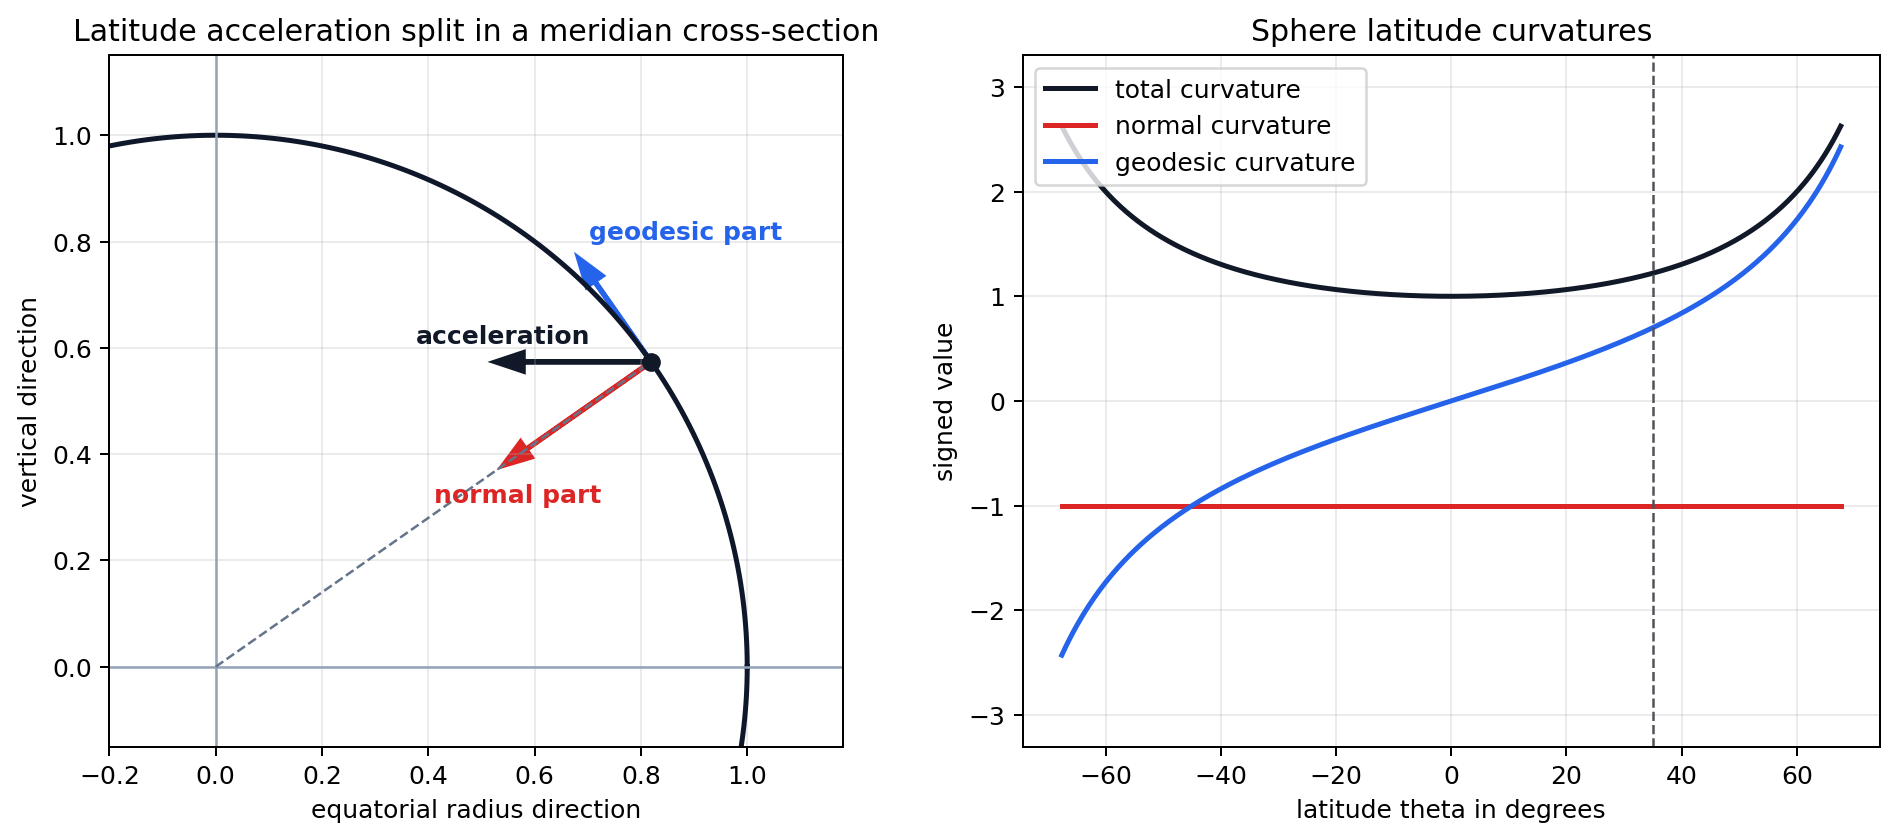

,theta_degrees,kappa,kappa_n_outward,kappa_g_signed,identity_residual
0,-60,2.000000,-1.0,-1.732051,0.0
1,-35,1.220775,-1.0,-0.700208,0.0
2,0,1.000000,-1.0,0.000000,0.0
3,35,1.220775,-1.0,0.700208,0.0
4,60,2.000000,-1.0,1.732051,0.0


In [4]:
theta0 = math.radians(35)
c0, s0 = math.cos(theta0), math.sin(theta0)
point_cross = np.array([c0, s0])
acc_cross = np.array([-1 / c0, 0.0])
normal_component = -point_cross
geodesic_component = acc_cross - normal_component

latitudes = np.linspace(-1.18, 1.18, 400)
kappa_total = 1 / np.cos(latitudes)
kappa_normal = -np.ones_like(latitudes)
kappa_geodesic = np.tan(latitudes)
curvature_identity_residual = float(np.max(np.abs(kappa_total**2 - kappa_normal**2 - kappa_geodesic**2)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8))
angle = np.linspace(0, 2 * np.pi, 400)
ax1.plot(np.cos(angle), np.sin(angle), color="#0f172a", linewidth=2)
ax1.axhline(0, color="#94a3b8", linewidth=1)
ax1.axvline(0, color="#94a3b8", linewidth=1)
ax1.scatter([point_cross[0]], [point_cross[1]], color="#111827", s=42, zorder=4)
ax1.plot([0, point_cross[0]], [0, point_cross[1]], color="#64748b", linestyle="--", linewidth=1)


def arrow2(ax, start, vec, color, label, scale=0.34, text_offset=(0.0, 0.0)):
    ax.arrow(start[0], start[1], scale * vec[0], scale * vec[1], head_width=0.035, length_includes_head=True, color=color, linewidth=2)
    end = start + scale * vec
    ax.text(end[0] + text_offset[0], end[1] + text_offset[1], label, color=color, fontsize=10, weight="bold")


arrow2(ax1, point_cross, acc_cross, "#111827", "acceleration", scale=0.24, text_offset=(-0.15, 0.035))
arrow2(ax1, point_cross, normal_component, "#dc2626", "normal part", scale=0.34, text_offset=(-0.13, -0.07))
arrow2(ax1, point_cross, geodesic_component, "#2563eb", "geodesic part", scale=0.34, text_offset=(0.02, 0.035))
ax1.set_title("Latitude acceleration split in a meridian cross-section")
ax1.set_xlabel("equatorial radius direction")
ax1.set_ylabel("vertical direction")
ax1.set_aspect("equal", adjustable="box")
ax1.set_xlim(-0.2, 1.18)
ax1.set_ylim(-0.15, 1.15)

ax2.plot(np.degrees(latitudes), kappa_total, label="total curvature", color="#111827", linewidth=2)
ax2.plot(np.degrees(latitudes), kappa_normal, label="normal curvature", color="#dc2626", linewidth=2)
ax2.plot(np.degrees(latitudes), kappa_geodesic, label="geodesic curvature", color="#2563eb", linewidth=2)
ax2.axvline(math.degrees(theta0), color="#52525b", linestyle="--", linewidth=1)
ax2.set_title("Sphere latitude curvatures")
ax2.set_xlabel("latitude theta in degrees")
ax2.set_ylabel("signed value")
ax2.set_ylim(-3.3, 3.3)
ax2.legend(loc="upper left")
fig.tight_layout()

curvature_path = FIGURE_DIR / "normal-geodesic-curvature-latitude.png"
fig.savefig(curvature_path, bbox_inches="tight")
plt.close(fig)

sample_degrees = [-60, -35, 0, 35, 60]
curvature_table = pd.DataFrame(
    [
        {
            "theta_degrees": deg,
            "kappa": 1 / math.cos(math.radians(deg)),
            "kappa_n_outward": -1.0,
            "kappa_g_signed": math.tan(math.radians(deg)),
            "identity_residual": abs((1 / math.cos(math.radians(deg))) ** 2 - 1 - math.tan(math.radians(deg)) ** 2),
        }
        for deg in sample_degrees
    ]
)
normal_geodesic_checks = {
    "identity_residual_grid": curvature_identity_residual,
    "theta0_degrees": math.degrees(theta0),
    "theta0_decomposition_residual": float(np.linalg.norm(acc_cross - normal_component - geodesic_component)),
    "theta0_geodesic_curvature": float(math.tan(theta0)),
}
normal_geodesic_path = save_json(normal_geodesic_checks, UNIT, "checks", "normal-geodesic-curvature-checks.json", root=ARTIFACT_ROOT)

display_artifact(curvature_path, width=920)
curvature_table


## 4. Covariant Derivative And Parallel Transport

For a tangent vector field `v(t)` along a curve `gamma(t)` on a surface, an outside observer sees `dv/dt` in `R^3`. A surface observer sees only the tangent projection

`nabla_gamma v = v_dot - (v_dot dot N) N`.

A vector field is parallel along `gamma` exactly when this tangent projection is zero. On the unit sphere, along a latitude `theta = theta0`, the coordinate vector field `v = alpha sigma_theta + beta sigma_phi` is parallel when

`alpha_dot = - beta sin(theta0) cos(theta0)`,

`beta_dot = alpha tan(theta0)`.

The interactive artifact solves these equations for a unit tangent vector initially pointing along the latitude. The transported vector keeps its length, stays tangent to the sphere, and usually stops pointing along the latitude unless the latitude is the equator.


In [5]:
def sphere_sigma(theta, phi):
    return np.array([np.cos(theta) * np.cos(phi), np.cos(theta) * np.sin(phi), np.sin(theta)], dtype=float)


def sphere_sigma_theta(theta, phi):
    return np.array([-np.sin(theta) * np.cos(phi), -np.sin(theta) * np.sin(phi), np.cos(theta)], dtype=float)


def sphere_sigma_phi(theta, phi):
    return np.array([-np.cos(theta) * np.sin(phi), np.cos(theta) * np.cos(phi), 0.0], dtype=float)


def sphere_sigma_theta_phi(theta, phi):
    return np.array([np.sin(theta) * np.sin(phi), -np.sin(theta) * np.cos(phi), 0.0], dtype=float)


def sphere_sigma_phi_phi(theta, phi):
    return np.array([-np.cos(theta) * np.cos(phi), -np.cos(theta) * np.sin(phi), 0.0], dtype=float)


def covariant_projection(vdot, normal):
    return vdot - np.dot(vdot, normal) * normal


def latitude_transport(theta_value, phi_values):
    cos_t = math.cos(theta_value)
    if abs(cos_t) < 1e-8:
        raise ValueError("latitude too close to a pole for this coordinate chart")

    def rhs(phi, y):
        alpha, beta = y
        return [-math.sin(theta_value) * math.cos(theta_value) * beta, math.tan(theta_value) * alpha]

    y0 = [0.0, 1.0 / cos_t]
    sol = solve_ivp(rhs, (float(phi_values[0]), float(phi_values[-1])), y0, t_eval=phi_values, rtol=1e-10, atol=1e-12)
    if not sol.success:
        raise RuntimeError(sol.message)
    alpha, beta = sol.y
    points = np.array([sphere_sigma(theta_value, ph) for ph in phi_values])
    sigma_t = np.array([sphere_sigma_theta(theta_value, ph) for ph in phi_values])
    sigma_p = np.array([sphere_sigma_phi(theta_value, ph) for ph in phi_values])
    sigma_tp = np.array([sphere_sigma_theta_phi(theta_value, ph) for ph in phi_values])
    sigma_pp = np.array([sphere_sigma_phi_phi(theta_value, ph) for ph in phi_values])
    vectors = alpha[:, None] * sigma_t + beta[:, None] * sigma_p
    rhs_values = np.array([rhs(ph, [a, b]) for ph, a, b in zip(phi_values, alpha, beta)])
    alpha_dot = rhs_values[:, 0]
    beta_dot = rhs_values[:, 1]
    vector_dot = alpha_dot[:, None] * sigma_t + alpha[:, None] * sigma_tp + beta_dot[:, None] * sigma_p + beta[:, None] * sigma_pp
    tangent_projection = np.array([covariant_projection(vd, n) for vd, n in zip(vector_dot, points)])
    e_phi = sigma_p / cos_t
    return {
        "alpha": alpha,
        "beta": beta,
        "points": points,
        "vectors": vectors,
        "vector_dot": vector_dot,
        "tangent_projection": tangent_projection,
        "e_phi": e_phi,
        "solution": sol,
    }


transport_theta = math.radians(35)
phis = np.linspace(0, 2 * np.pi, 161)
transport = latitude_transport(transport_theta, phis)
points = transport["points"]
vectors = transport["vectors"]
e_phi = transport["e_phi"]

norm_error = float(np.max(np.abs(np.linalg.norm(vectors, axis=1) - 1)))
tangent_error = float(np.max(np.abs(np.einsum("ij,ij->i", vectors, points))))
parallel_residual = float(np.max(np.linalg.norm(transport["tangent_projection"], axis=1)))
endpoint_dot_with_path_tangent = float(np.dot(vectors[-1], e_phi[-1]))
endpoint_angle_from_path_tangent = float(math.degrees(math.acos(np.clip(endpoint_dot_with_path_tangent, -1, 1))))

# Build a sphere and overlay the transported vectors.
theta_grid = np.linspace(-np.pi / 2 + 0.05, np.pi / 2 - 0.05, 45)
phi_grid = np.linspace(0, 2 * np.pi, 80)
TG, PG = np.meshgrid(theta_grid, phi_grid)
SX = np.cos(TG) * np.cos(PG)
SY = np.cos(TG) * np.sin(PG)
SZ = np.sin(TG)

fig = go.Figure()
fig.add_trace(go.Surface(x=SX, y=SY, z=SZ, colorscale=[[0, "#f8fafc"], [1, "#bfdbfe"]], opacity=0.38, showscale=False))
fig.add_trace(go.Scatter3d(x=points[:, 0], y=points[:, 1], z=points[:, 2], mode="lines", line=dict(color="#111827", width=5), name="latitude path"))
idx = np.linspace(0, len(phis) - 1, 18, dtype=int)
arrow_scale = 0.22
fig.add_trace(
    go.Cone(
        x=points[idx, 0], y=points[idx, 1], z=points[idx, 2],
        u=arrow_scale * vectors[idx, 0], v=arrow_scale * vectors[idx, 1], w=arrow_scale * vectors[idx, 2],
        anchor="tail", sizemode="absolute", sizeref=0.18,
        colorscale=[[0, "#2563eb"], [1, "#2563eb"]], showscale=False, name="parallel vector",
    )
)
fig.add_trace(
    go.Cone(
        x=points[idx, 0], y=points[idx, 1], z=points[idx, 2],
        u=0.16 * e_phi[idx, 0], v=0.16 * e_phi[idx, 1], w=0.16 * e_phi[idx, 2],
        anchor="tail", sizemode="absolute", sizeref=0.13,
        colorscale=[[0, "#9ca3af"], [1, "#9ca3af"]], showscale=False, name="path tangent",
        opacity=0.55,
    )
)
fig.update_layout(
    title="Parallel transport along a 35 degree latitude",
    height=650,
    margin=dict(l=0, r=0, t=45, b=0),
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    legend=dict(x=0.02, y=0.98),
)
transport_path = INTERACTIVE_DIR / "parallel-transport-latitude.html"
fig.write_html(transport_path, include_plotlyjs=True, full_html=True)

transport_checks = {
    "theta_degrees": math.degrees(transport_theta),
    "max_norm_error": norm_error,
    "max_tangent_error": tangent_error,
    "max_covariant_derivative_residual": parallel_residual,
    "endpoint_dot_with_path_tangent": endpoint_dot_with_path_tangent,
    "endpoint_angle_from_path_tangent_degrees": endpoint_angle_from_path_tangent,
}
transport_checks_path = save_json(transport_checks, UNIT, "checks", "parallel-transport-checks.json", root=ARTIFACT_ROOT)

display_artifact(transport_path, width="100%", height=580)
pd.DataFrame([transport_checks])


,theta_degrees,max_norm_error,max_tangent_error,max_covariant_derivative_residual,endpoint_dot_with_path_tangent,endpoint_angle_from_path_tangent_degrees
0,35.0,4.085909e-11,1.214306e-16,1.755417e-16,-0.895032,153.512483


## Proof And Invariant Scaffold

Three differentiations drive the chapter.

1. Since `N dot sigma_u = N dot sigma_v = 0`, differentiating gives `N_u dot sigma_u = -L`, `N_u dot sigma_v = N_v dot sigma_u = -M`, and `N_v dot sigma_v = -Ncoef`. This is the bridge from the Gauss map to the second fundamental form.
2. Since `N dot gamma_dot = 0`, differentiating along a curve gives `N dot gamma_ddot = -N_dot dot gamma_dot = II(gamma_dot,gamma_dot)`. This is why normal curvature depends only on the tangent direction at the point, not on the rest of the curve.
3. If two vector fields are parallel, their ordinary derivatives are normal to the surface. The derivative of their dot product is therefore zero. Parallel transport is linear and preserves lengths and angles.

The notebook checks these statements in exact symbolic examples, matrix residuals, a curvature decomposition, and an ODE transport computation.


## Applied Lab: Change The Direction, Latitude, And Orientation

The lab below gives small inputs to modify. Change the latitude values, the direction angles, or the sampled point on the paraboloid. The point of the table is not to produce a theorem by sampling; it is to make the chapter's invariants visible enough that a failed row would tell you what concept broke.


In [6]:
lab_rows = []
for deg in [-50, -25, 0, 25, 50]:
    th = math.radians(deg)
    residual = abs((1 / math.cos(th)) ** 2 - 1 - math.tan(th) ** 2)
    lab_rows.append(
        {
            "experiment": "sphere latitude curvature",
            "parameter": f"theta={deg} deg",
            "quantity_a": "kappa_n outward",
            "value_a": -1.0,
            "quantity_b": "kappa_g signed",
            "value_b": math.tan(th),
            "residual": residual,
        }
    )

sample_point = (0.35, -0.25)
I0, II0, W0 = paraboloid_forms(*sample_point)
for deg in [0, 30, 60, 90, 120, 150]:
    direction = np.array([math.cos(math.radians(deg)), math.sin(math.radians(deg))])
    normal_curvature = float(direction @ II0 @ direction / (direction @ I0 @ direction))
    lab_rows.append(
        {
            "experiment": "paraboloid direction normal curvature",
            "parameter": f"angle={deg} deg at u={sample_point[0]}, v={sample_point[1]}",
            "quantity_a": "II(v,v)/I(v,v)",
            "value_a": normal_curvature,
            "quantity_b": "metric length squared",
            "value_b": float(direction @ I0 @ direction),
            "residual": float(np.linalg.norm(W0.T @ I0 - I0 @ W0)),
        }
    )

for deg in [0, 20, 35, 50]:
    th = math.radians(deg)
    ph = np.linspace(0, 2 * np.pi, 121)
    tr = latitude_transport(th, ph)
    norm_err = float(np.max(np.abs(np.linalg.norm(tr["vectors"], axis=1) - 1)))
    endpoint_dot = float(np.dot(tr["vectors"][-1], tr["e_phi"][-1]))
    lab_rows.append(
        {
            "experiment": "parallel transport around latitude",
            "parameter": f"theta={deg} deg",
            "quantity_a": "endpoint dot path tangent",
            "value_a": endpoint_dot,
            "quantity_b": "max norm error",
            "value_b": norm_err,
            "residual": float(np.max(np.linalg.norm(tr["tangent_projection"], axis=1))),
        }
    )

lab_table = pd.DataFrame(lab_rows)
lab_table_path = TABLE_DIR / "applied-lab-curvature-transport.csv"
lab_table.to_csv(lab_table_path, index=False)
lab_table


,experiment,parameter,quantity_a,value_a,quantity_b,value_b,residual
0,sphere latitude curvature,theta=-50 deg,kappa_n outward,-1.000000,kappa_g signed,-1.191754e+00,0.000000e+00
1,sphere latitude curvature,theta=-25 deg,kappa_n outward,-1.000000,kappa_g signed,-4.663077e-01,8.326673e-17
2,sphere latitude curvature,theta=0 deg,kappa_n outward,-1.000000,kappa_g signed,0.000000e+00,0.000000e+00
3,sphere latitude curvature,theta=25 deg,kappa_n outward,-1.000000,kappa_g signed,4.663077e-01,8.326673e-17
4,sphere latitude curvature,theta=50 deg,kappa_n outward,-1.000000,kappa_g signed,1.191754e+00,0.000000e+00
5,paraboloid direction normal curvature,"angle=0 deg at u=0.35, v=-0.25","II(v,v)/I(v,v)",1.017581,metric length squared,1.490000e+00,2.406895e-18
6,paraboloid direction normal curvature,"angle=30 deg at u=0.35, v=-0.25","II(v,v)/I(v,v)",1.345468,metric length squared,1.126891e+00,2.406895e-18
7,paraboloid direction normal curvature,"angle=60 deg at u=0.35, v=-0.25","II(v,v)/I(v,v)",1.505819,metric length squared,1.006891e+00,2.406895e-18
8,paraboloid direction normal curvature,"angle=90 deg at u=0.35, v=-0.25","II(v,v)/I(v,v)",1.212957,metric length squared,1.250000e+00,2.406895e-18
9,paraboloid direction normal curvature,"angle=120 deg at u=0.35, v=-0.25","II(v,v)/I(v,v)",0.939922,metric length squared,1.613109e+00,2.406895e-18


## Final Sanity Checks

The final cell asserts the minimum contract for this notebook: artifacts exist and are nonempty, symbolic identities are true, numeric residuals are small, and the applied-lab table was written under the chapter artifact subtree.


In [7]:
artifact_paths = [
    source_span_path,
    storyboard_path,
    second_form_path,
    symbolic_path,
    gauss_map_path,
    gauss_checks_path,
    curvature_path,
    normal_geodesic_path,
    transport_path,
    transport_checks_path,
    lab_table_path,
]
for path in artifact_paths:
    min_bytes = 128
    if path.suffix.lower() in {".png", ".html"}:
        min_bytes = 1024
    assert_artifact(path, min_bytes=min_bytes)

final_sanity = {
    "unit": UNIT,
    "source_span": source_span,
    "artifacts": [book_rel(path) for path in artifact_paths],
    "symbolic_checks": {
        "sphere_II_equals_I_inward": symbolic_checks["sphere_inward_orientation"]["II_equals_I"],
        "cylinder_II_is_dv_squared_inward": symbolic_checks["unit_cylinder_inward_orientation"]["II_is_dv_squared"],
        "quadratic_model_has_both_signs": symbolic_checks["local_quadratic_model"]["has_positive_and_negative_normal_bending"],
    },
    "numeric_checks": {
        "gauss_max_normal_length_error": gauss_checks["max_normal_length_error"],
        "weingarten_max_self_adjoint_residual": gauss_checks["max_self_adjoint_residual"],
        "normal_geodesic_identity_residual": normal_geodesic_checks["identity_residual_grid"],
        "parallel_transport_max_norm_error": transport_checks["max_norm_error"],
        "parallel_transport_covariant_derivative_residual": transport_checks["max_covariant_derivative_residual"],
    },
    "lab_rows": int(len(lab_table)),
}

assert final_sanity["symbolic_checks"]["sphere_II_equals_I_inward"]
assert final_sanity["symbolic_checks"]["cylinder_II_is_dv_squared_inward"]
assert final_sanity["symbolic_checks"]["quadratic_model_has_both_signs"]
assert final_sanity["numeric_checks"]["gauss_max_normal_length_error"] < 1e-12
assert final_sanity["numeric_checks"]["weingarten_max_self_adjoint_residual"] < 1e-12
assert final_sanity["numeric_checks"]["normal_geodesic_identity_residual"] < 1e-12
assert final_sanity["numeric_checks"]["parallel_transport_max_norm_error"] < 1e-8
assert final_sanity["numeric_checks"]["parallel_transport_covariant_derivative_residual"] < 1e-8
assert final_sanity["lab_rows"] >= 10

final_sanity["artifacts"].append(book_rel(CHECK_DIR / "final-sanity.json"))
final_sanity_path = save_json(final_sanity, UNIT, "checks", "final-sanity.json", root=ARTIFACT_ROOT)
assert_artifact(final_sanity_path, min_bytes=512)
final_sanity


{'unit': 'chapter-07',
 'source_span': {'title': 'Curvature of surfaces',
  'unit': 'chapter-07',
  'printed_pages': '159-178',
  'pdf_pages': '164-182',
  'sections': '7.1-7.4',
  'source_use': 'orientation only; original notebook prose and visuals'},
 'artifacts': ['artifacts/chapter-07/checks/source-span.json',
  'artifacts/chapter-07/checks/visual-storyboard.json',
  'artifacts/chapter-07/figures/second-fundamental-form-deviation.png',
  'artifacts/chapter-07/checks/symbolic-fundamental-forms.json',
  'artifacts/chapter-07/interactive/gauss-map-paraboloid.html',
  'artifacts/chapter-07/checks/gauss-weingarten-checks.json',
  'artifacts/chapter-07/figures/normal-geodesic-curvature-latitude.png',
  'artifacts/chapter-07/checks/normal-geodesic-curvature-checks.json',
  'artifacts/chapter-07/interactive/parallel-transport-latitude.html',
  'artifacts/chapter-07/checks/parallel-transport-checks.json',
  'artifacts/chapter-07/tables/applied-lab-curvature-transport.csv',
  'artifacts/chap

## Takeaways

- The second fundamental form is the quadratic normal part of a surface patch after the tangent plane has absorbed all first-order motion.
- The Gauss map stores the unit normal field; its derivative gives the Weingarten map, and `II(v,w) = I(Wv,w)` makes the map self-adjoint for the surface metric.
- Normal curvature is the `N` component of curve acceleration and equals `II(gamma_dot,gamma_dot)` for unit-speed curves.
- Geodesic curvature is the tangential component of acceleration, so it is what a surface-bound observer experiences as turning.
- The covariant derivative is ordinary differentiation followed by tangent projection; parallel transport is the zero-covariant-derivative case and preserves dot products along the chosen curve.
